|██████████| 100.0% ◆ elapsed 2.57ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 1.02ms ◆ remaining 0.00ms


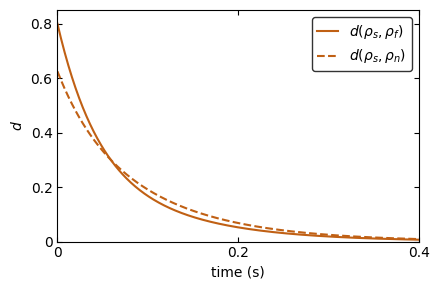

In [5]:
import jax
import jax.numpy as jnp
import dynamiqs as dq
import matplotlib.pyplot as plt

# 1. Define system parameters
gamma_minus = 17.5
gamma_plus = 2.5

H = 0.0 * dq.sigmaz() 

jump_ops = [
    jnp.sqrt(gamma_minus) * dq.sigmam(),
    jnp.sqrt(gamma_plus) * dq.sigmap()
]

# 2. Define the exact density matrices
rho_s = jnp.array([[0.125, 0.0], 
                   [0.0, 0.875]], dtype=jnp.complex64)

rho_n = jnp.array([[0.5, -0.5j], 
                   [0.5j, 0.5]], dtype=jnp.complex64)

val = jnp.sqrt(22311) / 400
rho_f = jnp.array([[0.8325, -1j * val], 
                   [1j * val, 0.1675]], dtype=jnp.complex64)

# 3. Simulate the dynamics
tsave = jnp.linspace(0, 0.4, 400)

result_n = dq.mesolve(H, jump_ops, rho_n, tsave)
result_f = dq.mesolve(H, jump_ops, rho_f, tsave)

# 4. Calculate Trace Distance over time using JAX vmap
@jax.jit
@jax.vmap
def trace_distance(rho_t):
    diff = rho_t - rho_s
    return jnp.sqrt(jnp.abs(jnp.linalg.det(diff)))

states_n = result_n.states.to_jax()
states_f = result_f.states.to_jax()

dist_n = trace_distance(states_n)
dist_f = trace_distance(states_f)

# 5. Plotting to match your Overleaf figure exactly
plt.figure(figsize=(4.5, 3))
line_color = '#C06014' 

# Removed the fake text dashes from the labels
plt.plot(tsave, dist_f, label=r'$d(\rho_s, \rho_f)$', color=line_color, linewidth=1.5)
plt.plot(tsave, dist_n, label=r'$d(\rho_s, \rho_n)$', color=line_color, linewidth=1.5, linestyle='--')

plt.xlabel('time (s)')
plt.ylabel(r'$d$')

# Set precise limits
plt.xlim(0, 0.4)
plt.ylim(0, 0.85)

# Match exact ticks from the Overleaf image
plt.xticks([0, 0.2, 0.4], ['0', '0.2', '0.4'])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8], ['0', '0.2', '0.4', '0.6', '0.8'])

# Restored handlelength so the actual colored lines show up in the legend
plt.legend(loc='upper right', frameon=True, edgecolor='black', handlelength=1.5)

plt.tick_params(direction='in', top=True, right=True)
plt.tight_layout()

plt.show()